In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/model_fake_data.csv')
df.head(2)

,clean_text,text_length,telecommuting,has_company_logo,has_questions,missing_company_profile,missing_benefits,short_description,fraudulent
0,marketing intern us ny new york food created g...,2708,0,1,0,0,1,0,0
1,customer service cloud video production nz auc...,6217,0,1,0,0,0,0,0


In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=5
)


text_features = tfidf.fit_transform(df['clean_text'])

In [6]:
print(text_features.shape)

(17880, 5000)


In [7]:
tfidf.get_feature_names_out()[:100]

array(['aa', 'aabbf', 'aabbf ca', 'ab', 'ab da', 'ab ea', 'abc',
       'abc supply', 'abilities', 'ability', 'ability adapt',
       'ability build', 'ability communicate', 'ability effectively',
       'ability learn', 'ability manage', 'ability multi',
       'ability prioritize', 'ability take', 'ability work', 'able',
       'able multi', 'able perform', 'able work', 'abroad',
       'abroad conversational', 'abroad play', 'abroad us', 'absolutely',
       'ac', 'ac ca', 'ac month', 'academic', 'accept', 'acceptance',
       'access', 'accessible', 'accommodation', 'accommodations',
       'accommodationswillingness',
       'accommodationswillingness availability', 'accomplish',
       'accordance', 'according', 'account', 'account executive',
       'account management', 'account manager', 'accountability',
       'accountable', 'accountant', 'accounting', 'accounting auditing',
       'accounts', 'accredited', 'accuracy', 'accurate', 'accurately',
       'achieve', 'achieve goa

In [8]:
text_features[0].toarray()

array([[0., 0., 0., ..., 0., 0., 0.]])

In [11]:
df

,clean_text,text_length,telecommuting,has_company_logo,has_questions,missing_company_profile,missing_benefits,short_description,fraudulent
0,marketing intern us ny new york food created g...,2708,0,1,0,0,1,0,0
1,customer service cloud video production nz auc...,6217,0,1,0,0,0,0,0
2,commissioning machinery assistant cma us ia we...,2659,0,1,0,0,1,0,0
3,account executive washington dc us dc washingt...,5550,0,1,0,0,0,0,0
4,bill review manager us fl fort worth spotsourc...,4057,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...
17875,account director distribution ca toronto vend ...,5384,0,1,1,0,0,0,0
17876,payroll accountant us pa philadelphia weblinc ...,4835,0,1,1,0,0,0,0
17877,project cost control staff engineer cost contr...,2847,0,0,0,0,1,0,0
17878,graphic designer ng la lagos nemsia studios lo...,1317,0,0,1,1,0,0,0


In [12]:
num_features = df[
[
'text_length',
'telecommuting',
'has_company_logo',
'has_questions',
'missing_company_profile',
'missing_benefits',
'short_description'
]
]

In [13]:
from scipy.sparse import hstack

X = hstack([text_features, num_features])

In [10]:
print(X.shape)

(17880, 10007)


In [18]:
y = df['fraudulent']

In [12]:
X.toarray()

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

In [ ]:
y.head()

In [14]:
import pandas as pd

X = pd.DataFrame(X.toarray())

In [15]:
X.head()

,0,1,2,3,4,5,6,7,8,9,...,4997,4998,4999,5000,5001,5002,5003,5004,5005,5006
0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.000000,2708.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.017767,0.0,0.0,0.0,0.0,0.0,0.010043,...,0.0,0.0,0.000000,6217.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.000000,2659.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.016361,...,0.0,0.0,0.094564,5550.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.000000,4057.0,0.0,1.0,1.0,0.0,0.0,0.0


In [19]:
y

,fraudulent
0,0
1,0
2,0
3,0
4,0
...,...
17875,0
17876,0
17877,0
17878,0


In [20]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

In [19]:
print(X_train.shape)

(14304, 10007)


In [ ]:
print(X_test.shape)

(3576, 10007)


In [18]:
print(y_train.shape)

(14304,)


In [ ]:
print(y_test.shape)

(3576,)


In [20]:
##  Baseline model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight = 'balanced', max_iter = 1000)
model.fit(X_train , y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

In [21]:
from sklearn.metrics import classification_report , confusion_matrix
y_pred = model.predict(X_test)
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      3395
           1       0.51      0.91      0.65       181

    accuracy                           0.95      3576
   macro avg       0.75      0.93      0.81      3576
weighted avg       0.97      0.95      0.96      3576



In [22]:
print(confusion_matrix(y_test , y_pred))

[[3236  159]
 [  17  164]]


In [23]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators = 200 , class_weight = 'balanced' , random_state = 42)
model.fit(X_train , y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [24]:
y_pred = model.predict(X_test)
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3395
           1       1.00      0.60      0.75       181

    accuracy                           0.98      3576
   macro avg       0.99      0.80      0.87      3576
weighted avg       0.98      0.98      0.98      3576



In [25]:
from sklearn.metrics import confusion_matrix , accuracy_score
print(confusion_matrix(y_test , y_pred))
print(accuracy_score(y_test , y_pred))

[[3395    0]
 [  73  108]]
0.979586129753915


In [26]:
##3 .
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train , y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test , y_pred))
print(accuracy_score(y_test , y_pred))
print(confusion_matrix(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      3395
           1       0.55      0.36      0.44       181

    accuracy                           0.95      3576
   macro avg       0.76      0.67      0.71      3576
weighted avg       0.95      0.95      0.95      3576

0.9530201342281879
[[3342   53]
 [ 115   66]]


In [27]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    num_features = 200,
    max_depth = 5,
    learning_rate = 0.1,
    random_state = 42
)
xgb.fit(X_train , y_train)

y_pred = xgb.predict(X_test)
print(classification_report(y_test , y_pred))
print(accuracy_score(y_test , y_pred))
print(confusion_matrix(y_test , y_pred))
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb, X, y, cv=5, scoring='f1')

print(scores.mean())

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:47:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "num_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3395
           1       0.98      0.69      0.81       181

    accuracy                           0.98      3576
   macro avg       0.98      0.84      0.90      3576
weighted avg       0.98      0.98      0.98      3576

0.9832214765100671
[[3392    3]
 [  57  124]]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:51:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "num_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:55:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "num_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:59:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "num_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:03:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "num_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [1

0.7536094679215685


In [28]:
from sklearn.metrics  import roc_auc_score
y_prob = xgb.predict_proba(X_test)[:,1]
roc_auc_score(y_test , y_prob)

np.float64(0.986958396732276)

In [30]:
from sklearn.model_selection import cross_val_score

In [31]:
scores = cross_val_score(xgb , X , y , cv = 5 , scoring = 'f1')
print(scores)
print(scores.mean())

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:30:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "num_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:36:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "num_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:42:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "num_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:47:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "num_features" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [1

[0.78947368 0.6993007  0.7739726  0.74204947 0.76325088]
0.7536094679215685


In [32]:
models = {
    'LogisticRegression' : LogisticRegression(),
    'RandomForestClassifier' : RandomForestClassifier(),
    "Naive Bayes": MultinomialNB(),
    "XGBoost": XGBClassifier()

}

In [33]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score
import pandas as pd

results = []

for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        'model_name': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,model_name,accuracy,precision,recall,f1_score
0,LogisticRegression,0.959732,0.911111,0.226519,0.362832
1,RandomForestClassifier,0.980425,0.991150,0.618785,0.761905
2,Naive Bayes,0.953020,0.554622,0.364641,0.440000
3,XGBoost,0.984899,0.970370,0.723757,0.829114


In [34]:
results_df.sort_values(by = 'f1_score' , ascending = False)

,model_name,accuracy,precision,recall,f1_score
3,XGBoost,0.984899,0.970370,0.723757,0.829114
1,RandomForestClassifier,0.980425,0.991150,0.618785,0.761905
2,Naive Bayes,0.953020,0.554622,0.364641,0.440000
0,LogisticRegression,0.959732,0.911111,0.226519,0.362832


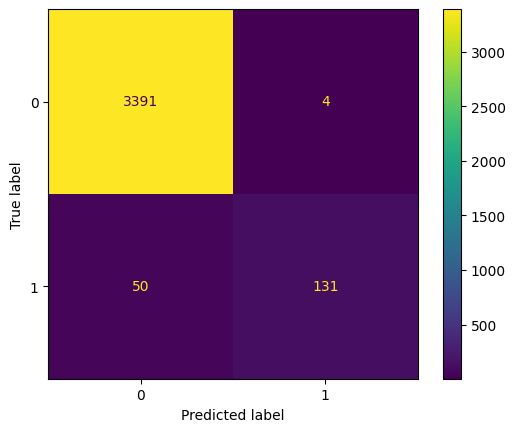

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [30]:
param_grid = {
    "n_estimators": [150, 200],
    "max_depth": [4, 5],
    "learning_rate": [0.05, 0.1]
}

In [31]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_jobs=-1
)

search = RandomizedSearchCV(
    xgb,
    param_grid,
    n_iter=4,   # very small search
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=2
)

search.fit(X_train, y_train)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           max_cat_threshold=None,
                                           max_cat_to_onehot=None,
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=-1,
                                           num_parallel_tree=None, ...),
                   n_iter=4, n_jobs=-1,
                   param_distributions={'learning_rate': [0.05, 0.1],
                                        'max_depth': [4, 5],
                                        'n_estimators': [150, 200]},
                   scoring='f1', verbose=2)

In [35]:
best_model = search.best_estimator_
best_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [33]:
y_pred = best_model.predict(X_test)

In [34]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3395
           1       0.98      0.69      0.81       181

    accuracy                           0.98      3576
   macro avg       0.98      0.84      0.90      3576
weighted avg       0.98      0.98      0.98      3576



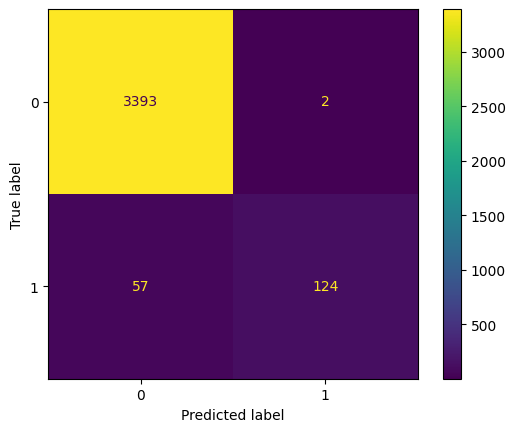

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

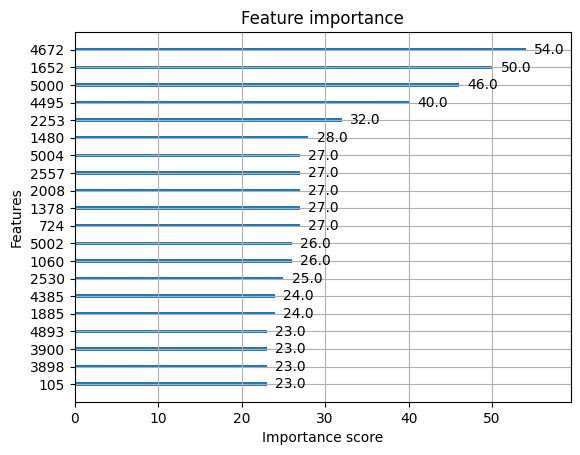

In [37]:
import xgboost as xgb
xgb.plot_importance(best_model, max_num_features=20)

In [47]:
XGBClassifier(scale_pos_weight=18)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [48]:
y_prob = best_model.predict_proba(X_test)[:,1]

y_pred = (y_prob > 0.4).astype(int)

In [49]:
errors = X_test[y_test != y_pred]

In [51]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3395
           1       0.98      0.71      0.83       181

    accuracy                           0.98      3576
   macro avg       0.98      0.86      0.91      3576
weighted avg       0.98      0.98      0.98      3576



In [57]:
import joblib

joblib.dump(best_model, "/content/drive/MyDrive/fake_job_model.pkl")

['/content/drive/MyDrive/fake_job_model.pkl']

In [59]:
print(best_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)


In [61]:
import joblib

joblib.dump(tfidf, "/content/drive/MyDrive/tfidf_vectorizer.pkl")

['/content/drive/MyDrive/tfidf_vectorizer.pkl']